# I-ROCKET Demo: Three Bumps Dataset

The "three bumps" dataset defines three classes by placing a Gaussian bump at a distinct temporal position (t=25, 50, 75) and adding Gaussian noise. Because we know exactly where the discriminative signal is, every visualization method can be validated against ground truth.  

This dataset was developed for early testing of the I-ROCKET package.

## 0. Setup

In [1]:
# Suppress OpenMP diagnostic messages that numba triggers on startup.
# These are informational only and do not affect results.
import os
os.environ["OMP_DISPLAY_ENV"] = "FALSE"
os.environ["KMP_WARNINGS"] = "0"

RANDOM_STATE = 42

## 1. Generate data and visualize the class structure

The three bumps generator creates time series of length 100 with a Gaussian bump at a class-specific position. The parameters control the difficulty:
- **amplitudes**: peak height of the bump (higher = easier)
- **sigma**: width of the bump in timepoints (wider = more signal energy)
- **noise_std**: background noise level (higher = harder)

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from three_bumps import generate_three_bumps, estimate_bayes_error

# Generate the dataset
amplitudes=3.0  # Peak amplitude of the bump for each class
sigma=5.0       # Standard deviation (width) of the Gaussian bump in timepoints
noise_std=1.5   # Standard deviation of the additive Gaussian noise.
X, y = generate_three_bumps(n_samples=5000, amplitudes=amplitudes,
                            sigma=sigma, noise_std=noise_std, random_state=42) # 42 <- Jackie Robinson

print(f"Dataset: {X.shape[0]} instances × {X.shape[1]} timepoints, 3 classes")

Dataset: 5000 instances × 100 timepoints, 3 classes


The plot below shows individual trials (thin lines) and class means
(thick lines) for each class. The gray dashed line marks the bump center.
Even in individual trials, the bump is visible above the noise — this is
what the classifier needs to detect.

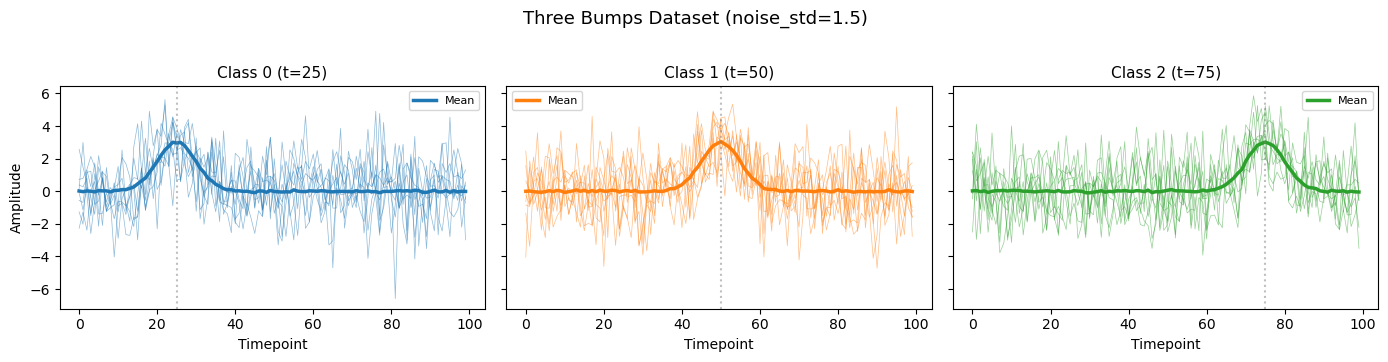

In [3]:
# Plot class-mean signals with individual trial examples
fig, axes = plt.subplots(1, 3, figsize=(14, 3.5), sharey=True)
class_names = ["Class 0 (t=25)", "Class 1 (t=50)", "Class 2 (t=75)"]
colors = ['tab:blue','tab:orange','tab:green']

for k in range(3):
    ax = axes[k]
    mask = y == k
    # Plot a few individual trials
    for i in np.where(mask)[0][:8]:
        ax.plot(X[i], color=colors[k], alpha=0.5, linewidth=0.5)
    # Plot class mean
    ax.plot(X[mask].mean(axis=0), color=colors[k], linewidth=2.5, label="Mean")
    ax.set_title(class_names[k], fontsize=11)
    ax.set_xlabel("Timepoint")
    if k == 0:
        ax.set_ylabel("Amplitude")
    ax.axvline(25 * (k + 1), color="gray", linestyle=":", alpha=0.5)
    ax.legend(fontsize=8)

fig.suptitle(f"Three Bumps Dataset (noise_std={noise_std})", fontsize=13, y=1.02)
plt.tight_layout()

## 2. Cross-Validated Model

In [4]:
import interp_rocket as IR

results = IR.cross_validate(
    X, y,
    n_repeats=5,
    n_folds=5,
    max_dilations_per_kernel=16,
    num_features=10000,
    random_state=RANDOM_STATE,
)

print(f"\n5x5 Cross-validation results:")
for metric in ['accuracy', 'balanced_accuracy', 'mcc']:
    m = results[metric]
    print(f"  {metric:>20s}: {m['mean']:.4f} +/- {m['std']:.4f}")

Cross-validation: 5 repeats × 5 folds = 25 evaluations
  Data: 5000 instances × 100 timepoints, 3 classes
  Class counts: {np.int64(0): 1688, np.int64(1): 1650, np.int64(2): 1662}
  Repeat  1/5: acc = 0.9996  bal_acc = 0.9996  mcc = 0.9994
  Repeat  2/5: acc = 0.9994  bal_acc = 0.9994  mcc = 0.9991
  Repeat  3/5: acc = 0.9996  bal_acc = 0.9996  mcc = 0.9994
  Repeat  4/5: acc = 0.9994  bal_acc = 0.9994  mcc = 0.9991
  Repeat  5/5: acc = 0.9996  bal_acc = 0.9996  mcc = 0.9994

  Results (mean ± std across 25 folds):
    accuracy            : 0.9995 ± 0.0007
    balanced_accuracy   : 0.9995 ± 0.0007
    f1_macro            : 0.9995 ± 0.0007
    f1_weighted         : 0.9995 ± 0.0007
    mcc                 : 0.9993 ± 0.0010
    mutual_info         : 1.5802 ± 0.0069

  Aggregated confusion matrix:
            0       1       2
     0    8435       0       5
     1       5    8245       0
     2       2       0    8308

5x5 Cross-validation results:
              accuracy: 0.9995 +/- 0.0007

## 3. Visualization of the full model

### Fit a model with all data for the purposes of interpretability

In [5]:
# Fit a reference model on all data for stability analysis
model = IR.InterpRocket(
    max_dilations_per_kernel=16,
    num_features=10000,
    random_state=RANDOM_STATE,
)
model.fit(X, y)

InterpRocket.fit: 5000 instances × 100 timepoints
  Classes: [0 1 2]
  Fitting dilations (raw)...
  Fitting biases (raw): 2436 biases across 4 dilations...
  Fitting dilations (diff)...
  Fitting biases (diff): 2436 biases across 4 dilations...
  Transforming training data...
  Feature matrix: (5000, 19488)
  Standardizing features...
  Fitting RidgeClassifierCV...
  Training accuracy: 1.0000
  Selected alpha: 4832.9302


,max_dilations_per_kernel,16
,num_features,10000
,random_state,42
,alpha_range,array([1.0000...00000000e+10])
,class_weight,None


### Top kernels

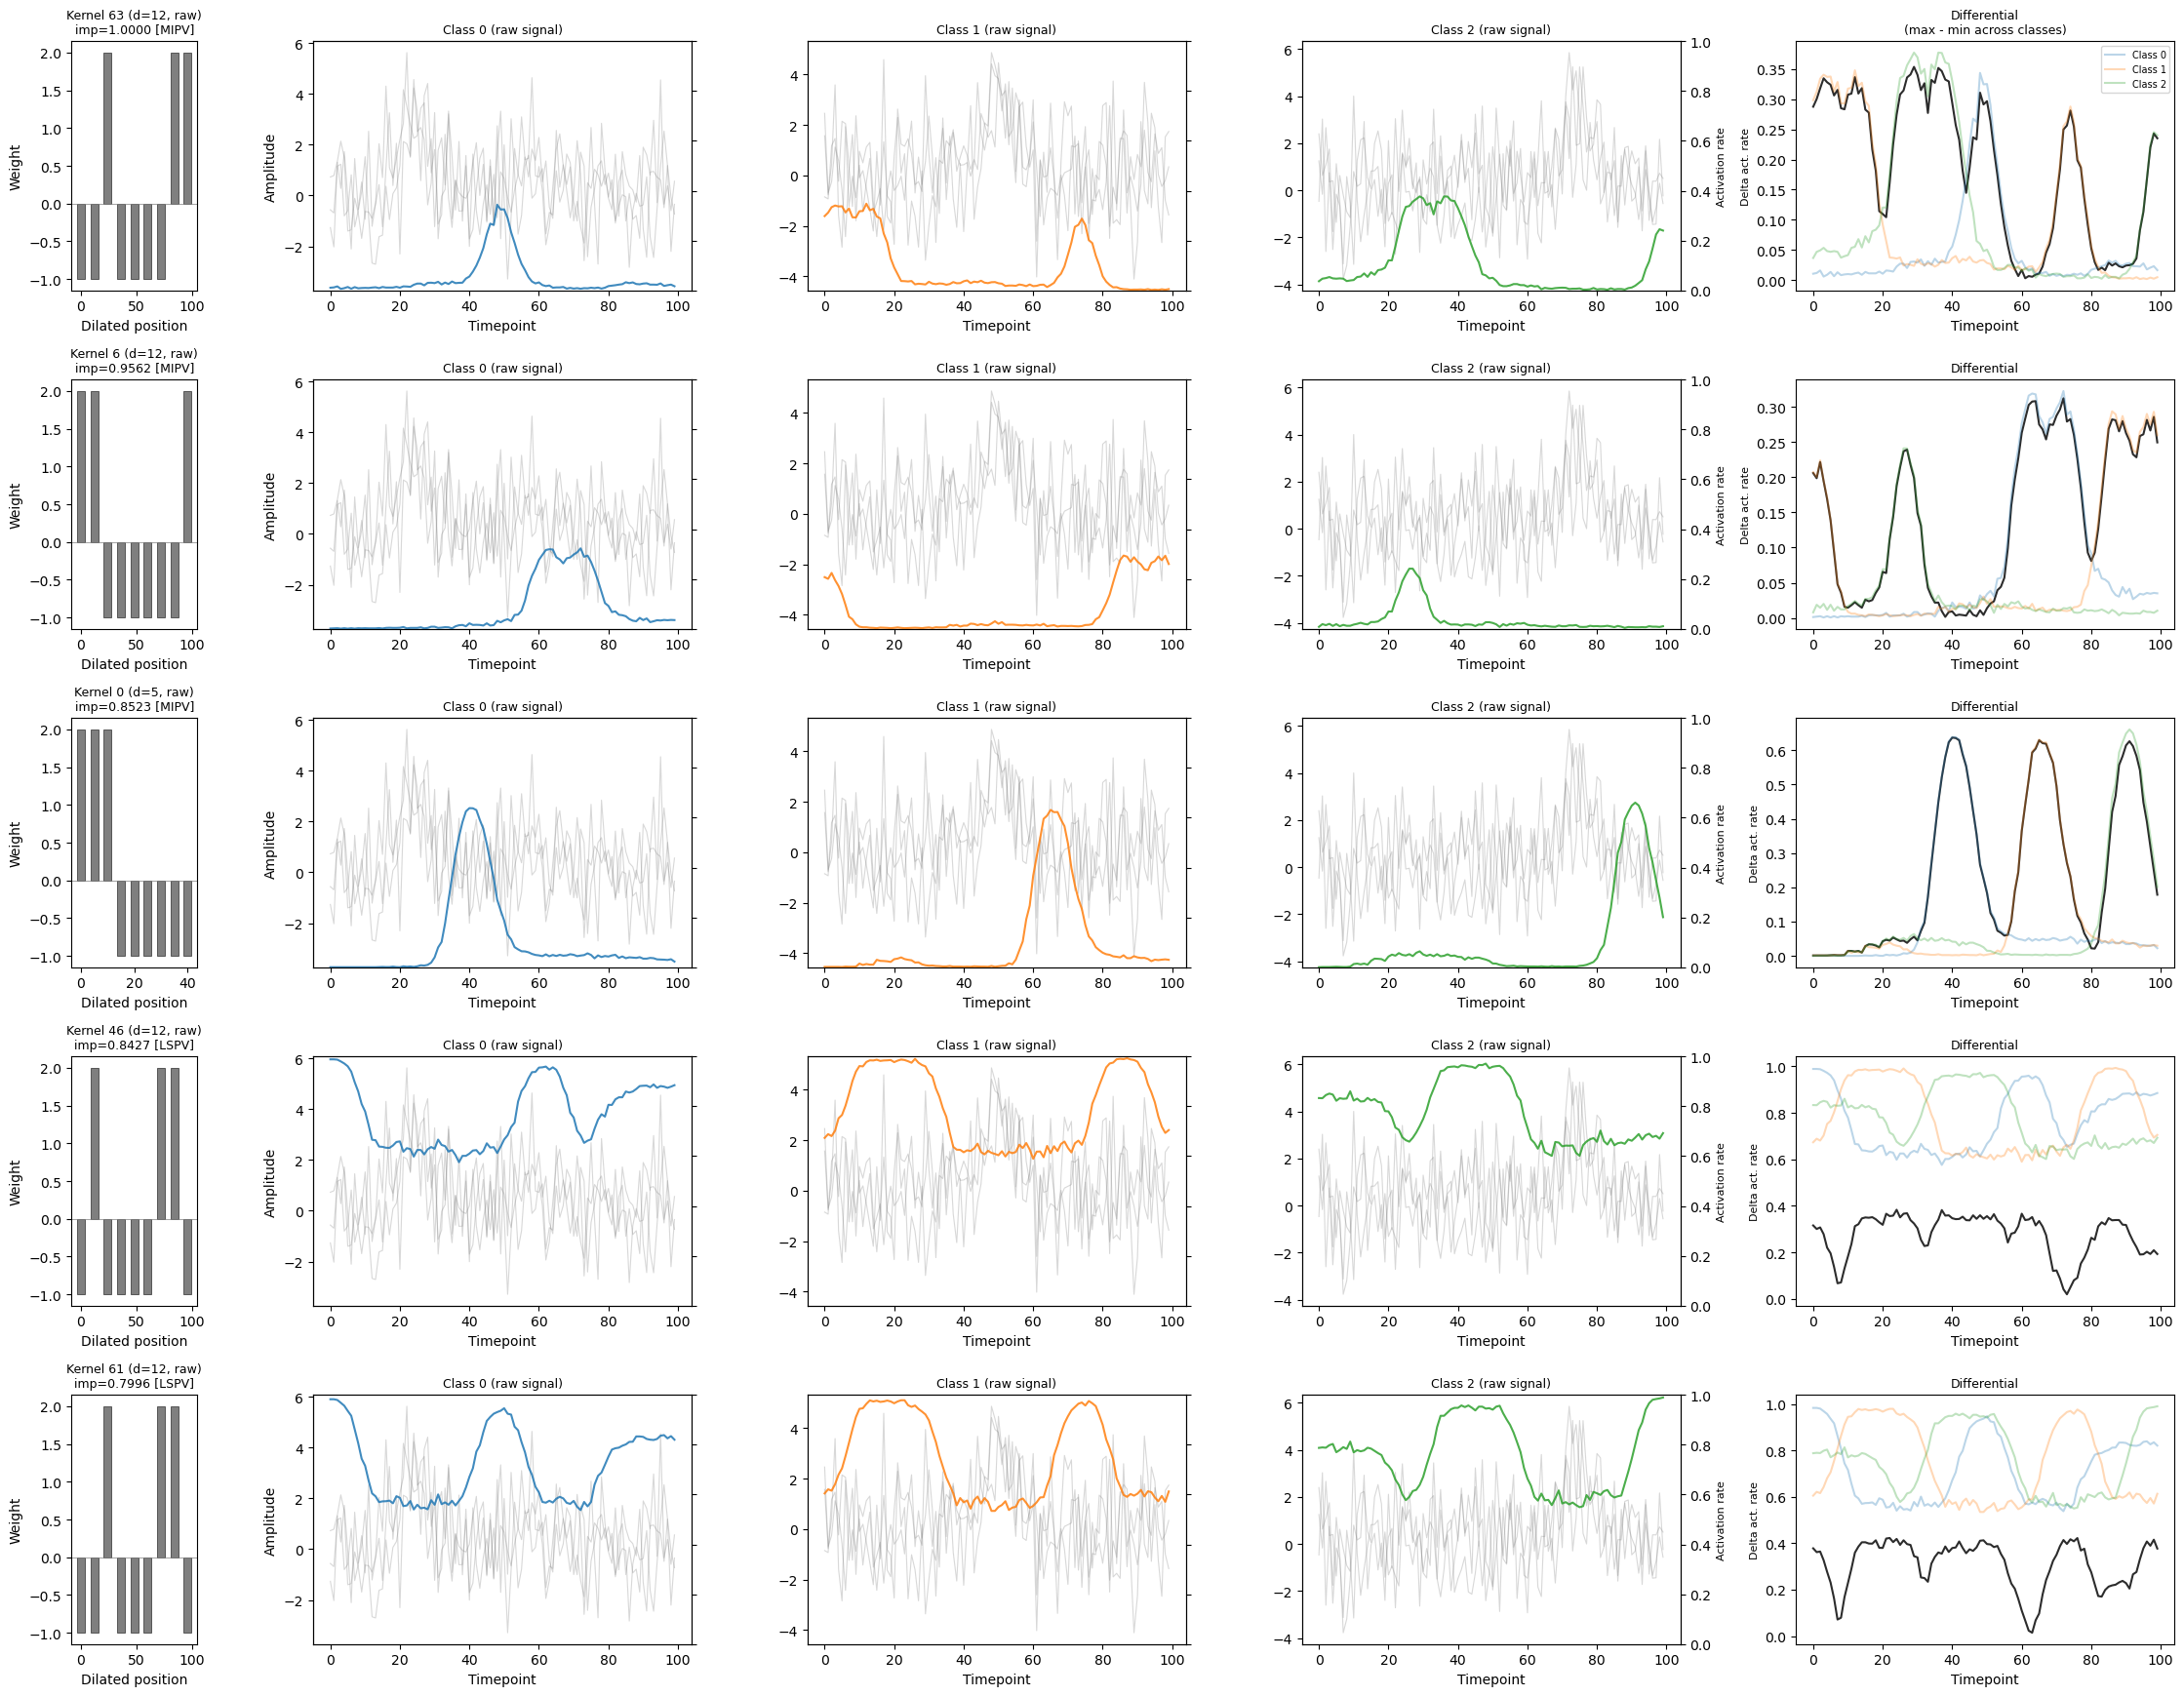

In [6]:
fig = model.plot_top_kernels(X, y, n_kernels=5)

### Temporal importance

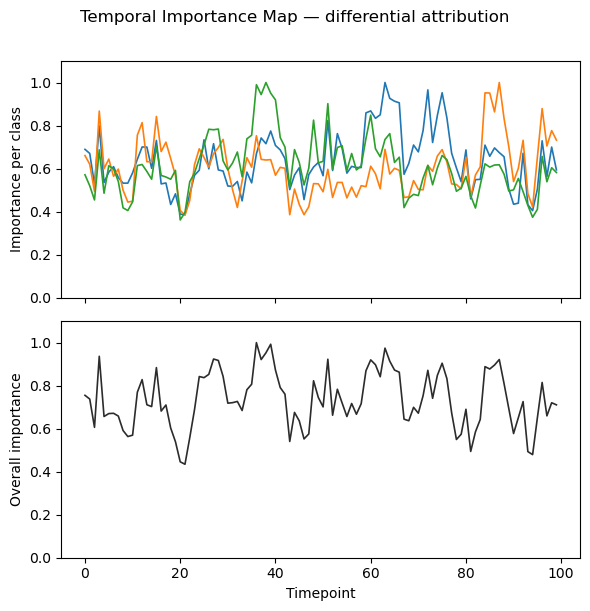

In [7]:
fig = model.plot_temporal_importance(X, y, figsize=(6, 6))

### Feature distributions

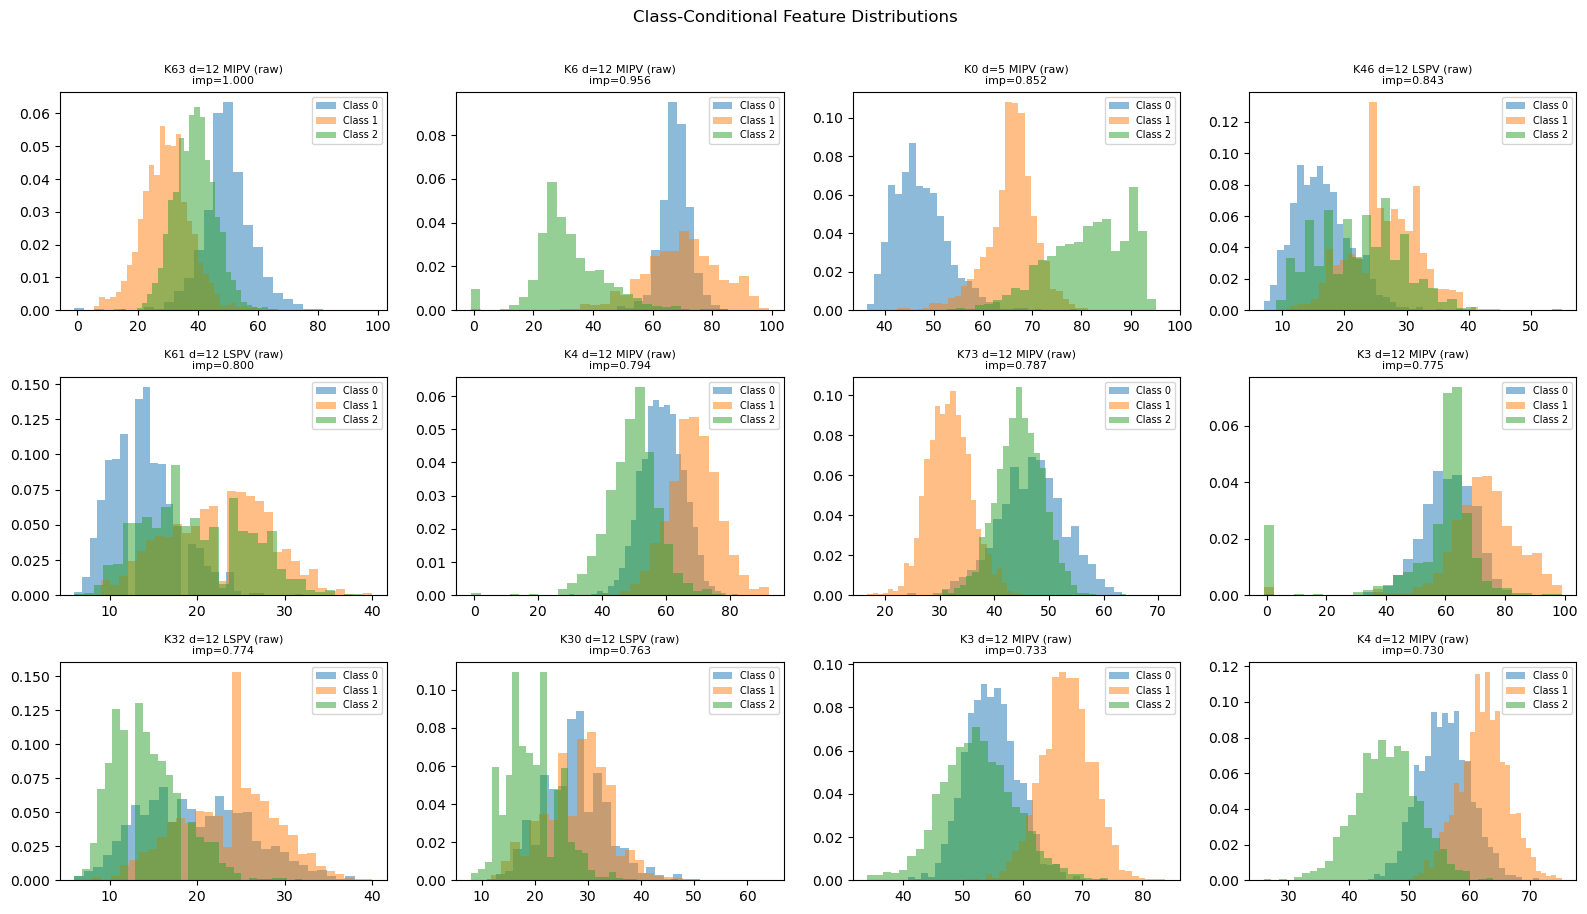

In [8]:
fig = model.plot_feature_distributions(X, y)

### Kernel properties

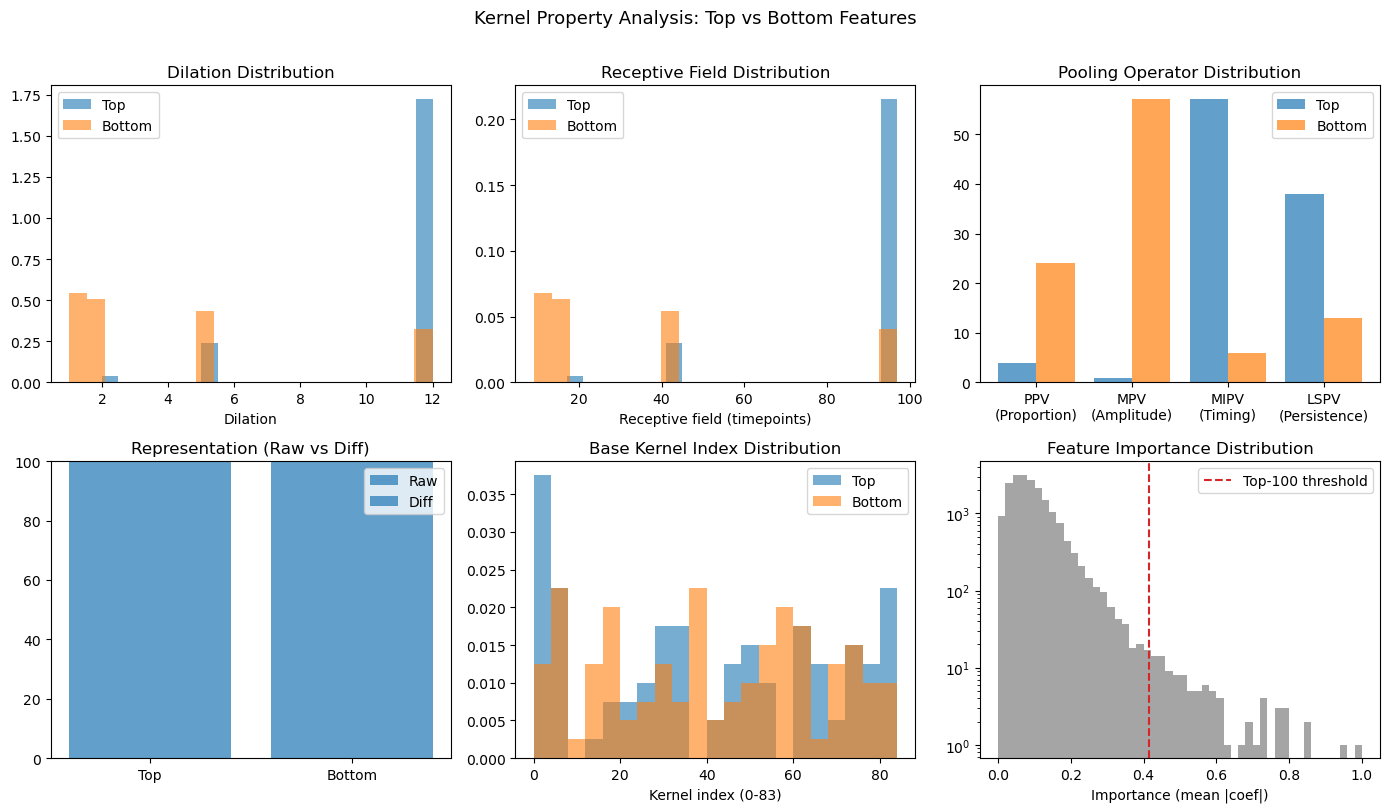

In [9]:
fig = model.plot_kernel_properties()

### Receptive Field Map

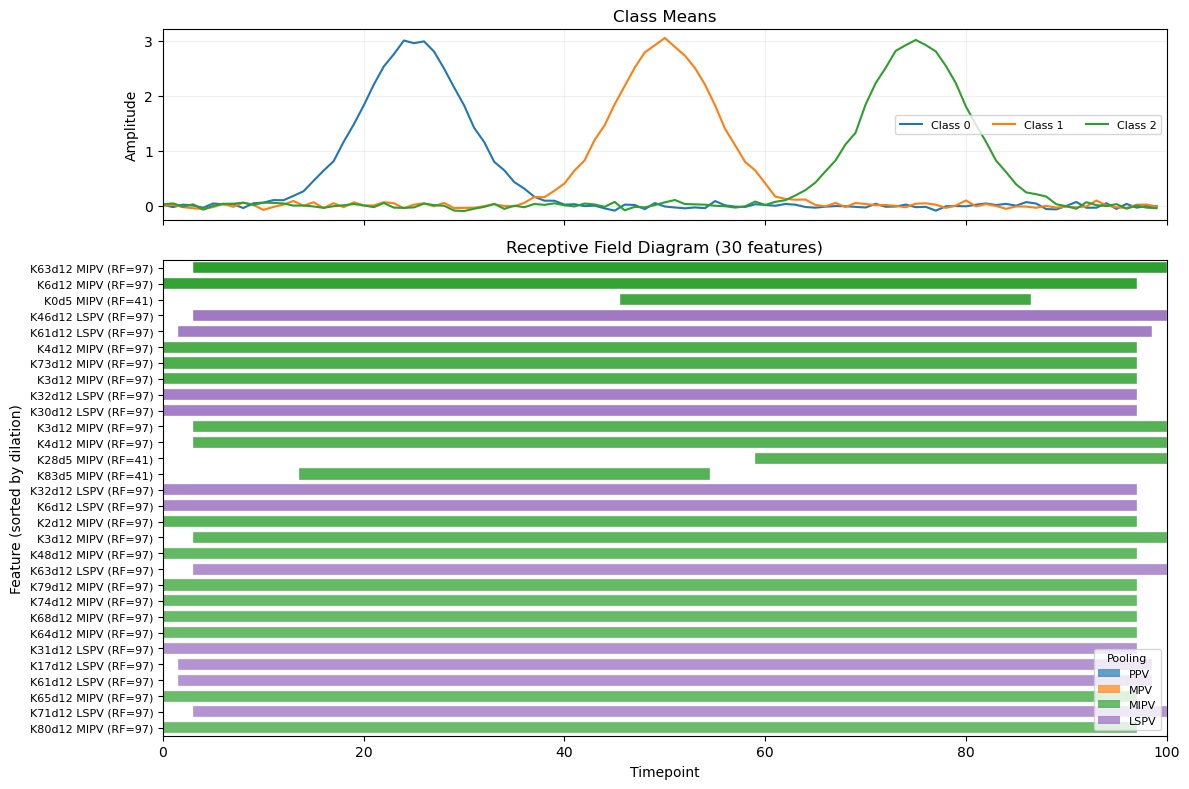

In [10]:
fig = IR.plot_receptive_field_diagram(model, X, y, n_top=30)

## 4. Feature Stability Using Cross-Validation

CV feature stability: 5x5 folds, tracking top 50 features per fold
  Round 1/5: 67 features appeared in every round so far
  Round 2/5: 66 features appeared in every round so far
  Round 3/5: 65 features appeared in every round so far
  Round 4/5: 68 features appeared in every round so far
  Round 5/5: 64 features appeared in every round so far

  Features in ALL folds:  31
  Features in ≥80% folds: 37
  Features in NO folds:   9325
Stable features (≥80% of 25 folds): 37


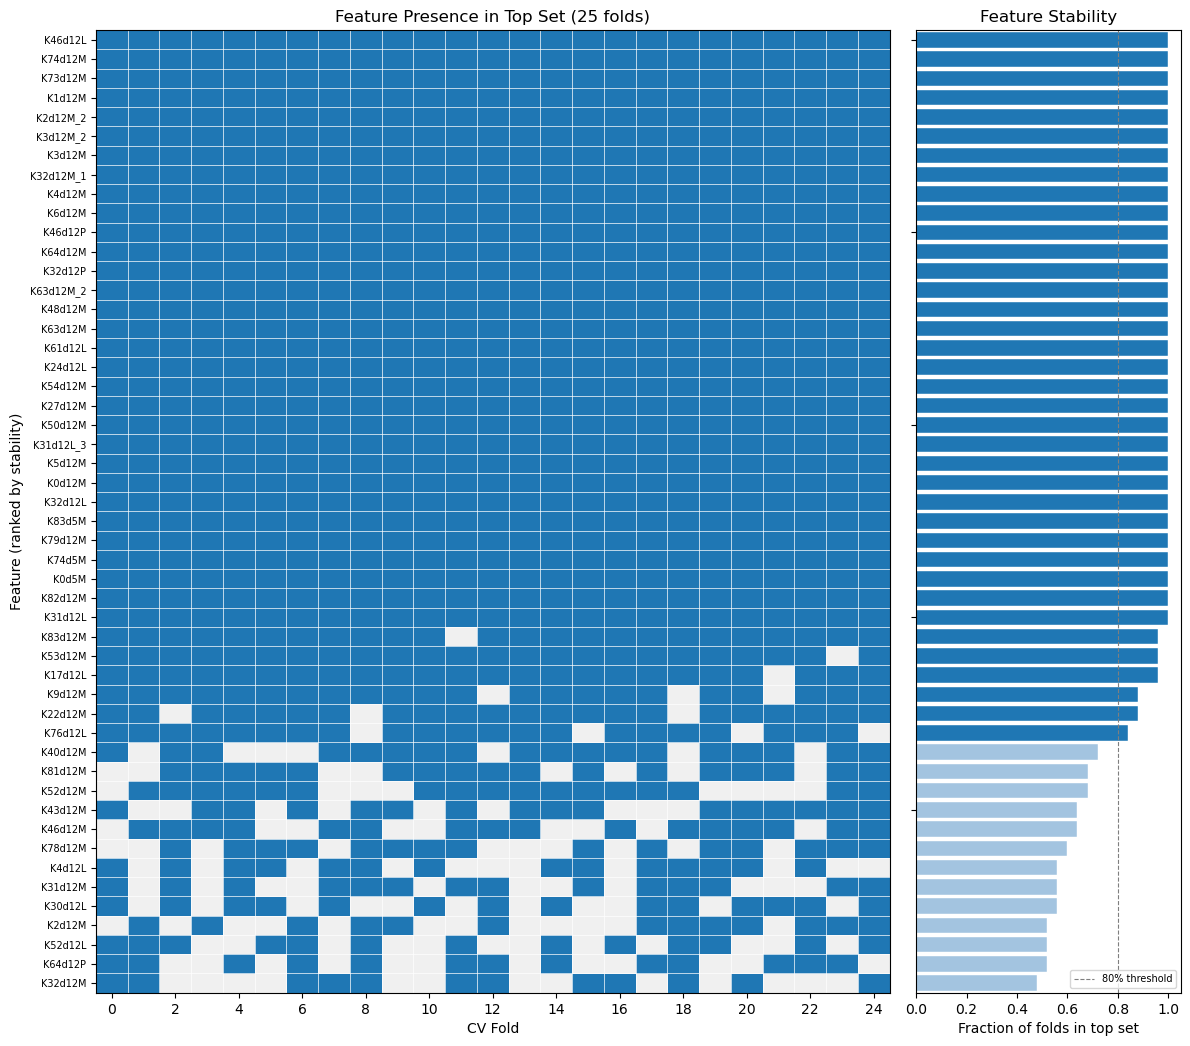

In [11]:
stability = IR.cv_feature_stability(X, y, n_repeats=5, n_folds=5, n_top=50)
fig = IR.plot_feature_stability(stability, model=model)

# Extract stable features at 80% threshold
stable_features = IR.get_stable_features(stability, threshold=0.8)

### Temporal Importance of Reduced Model

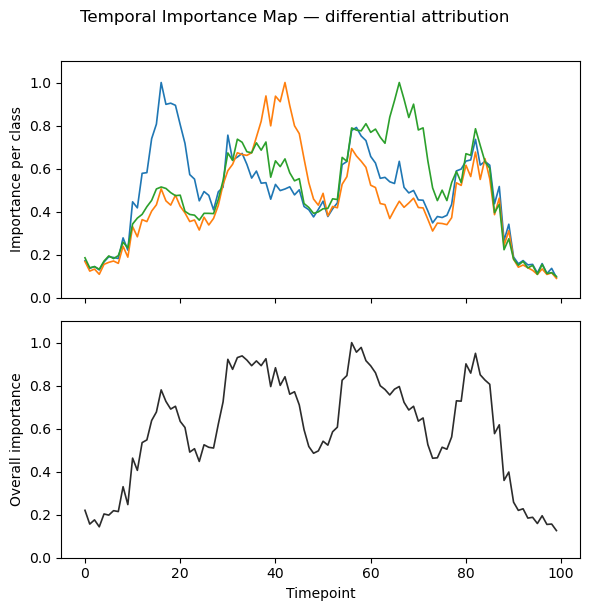

In [12]:
fig, imp_data = model.plot_temporal_importance(
    X, y, n_examples=100,
    feature_mask=stable_features, figsize=(6, 6),
)

### Receptive Fields of Reduced Model

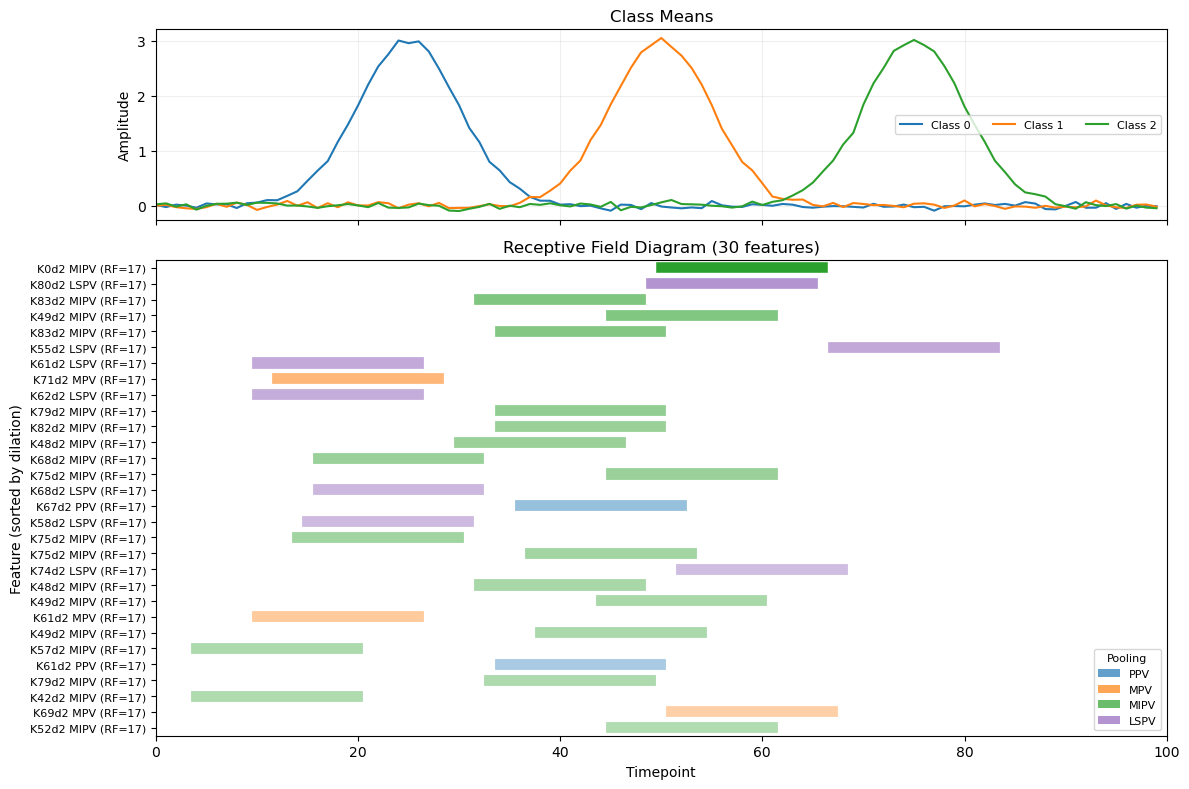

In [13]:
fig = IR.plot_receptive_field_diagram(model, X, y, feature_mask=stable_features, n_top=30)

### Information Decomposition

In [14]:
info = IR.information_decomposition(
    model, X, y,
    group_by='kernel',
    n_shuffles=100,
    feature_mask=stable_features,
)

Information decomposition: 37 features in 24 groups (kernel)
  Ensemble MI: 1.5849 bits
  Group 2/24: I_single=0.0000, I_loo=0.5262
  Group 4/24: I_single=0.0276, I_loo=0.5306
  Group 6/24: I_single=0.0665, I_loo=0.5326
  Group 8/24: I_single=0.0000, I_loo=0.5300
  Group 10/24: I_single=0.0000, I_loo=0.5299
  Group 12/24: I_single=0.0000, I_loo=0.5343
  Group 14/24: I_single=0.0000, I_loo=0.5353
  Group 16/24: I_single=0.0000, I_loo=0.5283
  Group 18/24: I_single=0.0000, I_loo=0.5322
  Group 20/24: I_single=0.1311, I_loo=0.5246
  Group 22/24: I_single=0.0000, I_loo=0.5327
  Group 24/24: I_single=0.1845, I_loo=0.5296
  Computing null distribution (100 shuffles)...

  Results (24 groups):
    Redundant:   0 (0.0%)
    Synergistic: 24 (100.0%)
    Independent: 0 (0.0%)
    Shuffle MI:  0.0283 ± 0.0469
    Ensemble MI: 1.5849
    Sum(I_single): 1.4166
    P_ensemble (I_ens - sum(I_single)): 0.1683


## 5. Class-mean kernel activation analysis

### Activation map of the class means

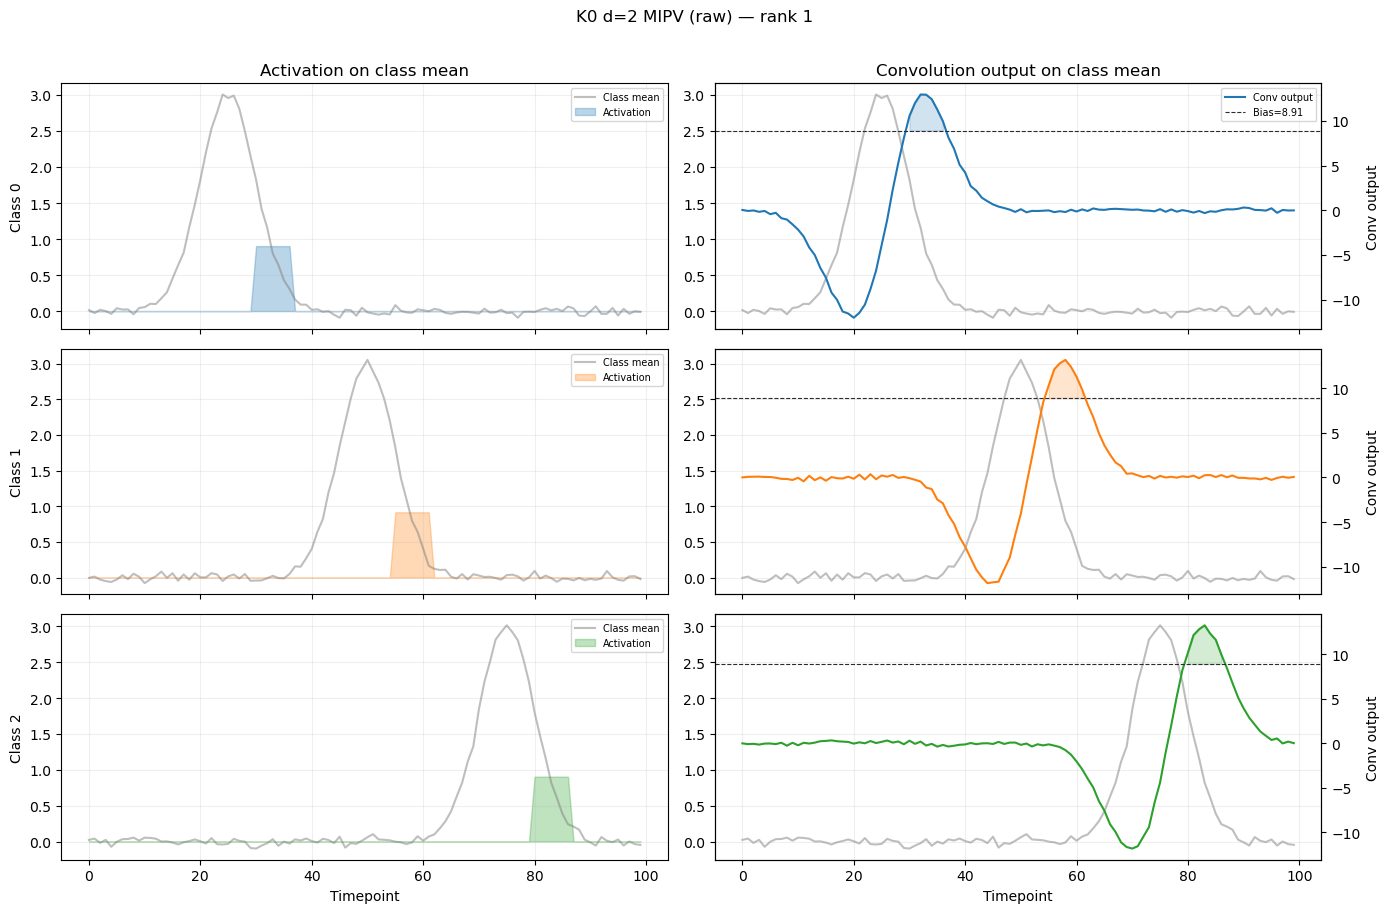

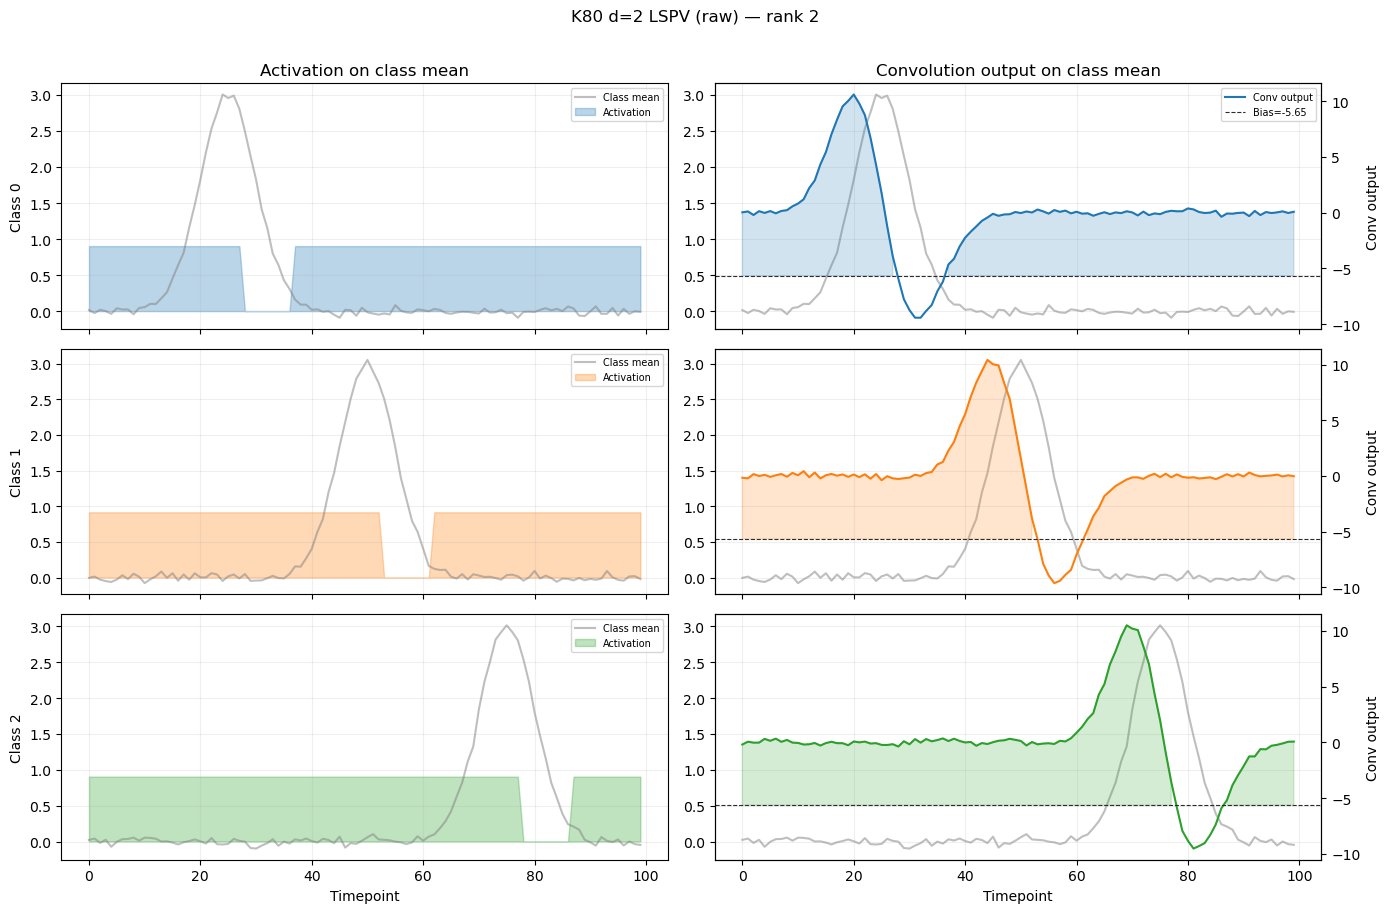

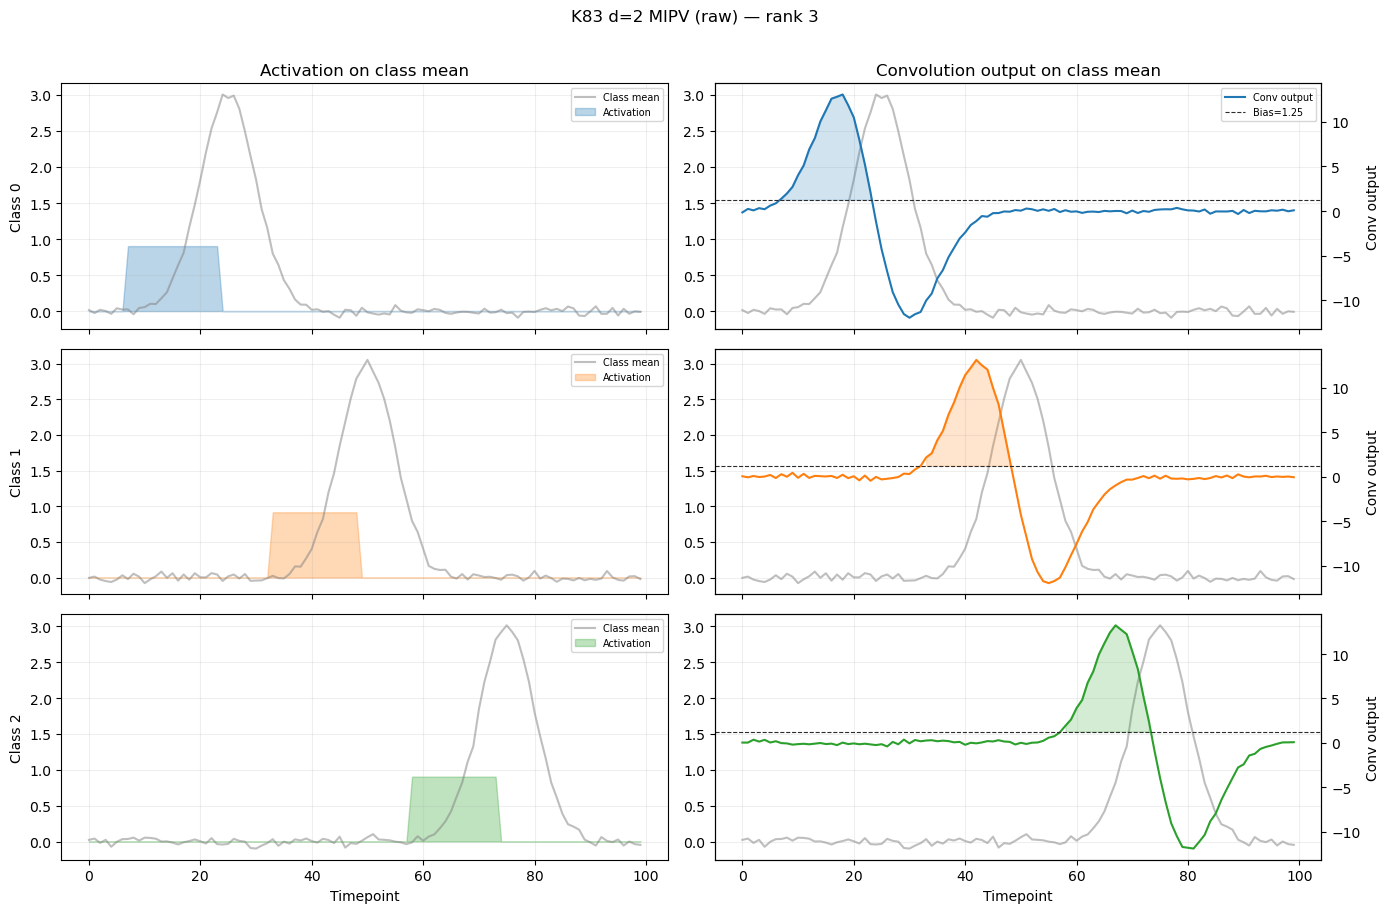

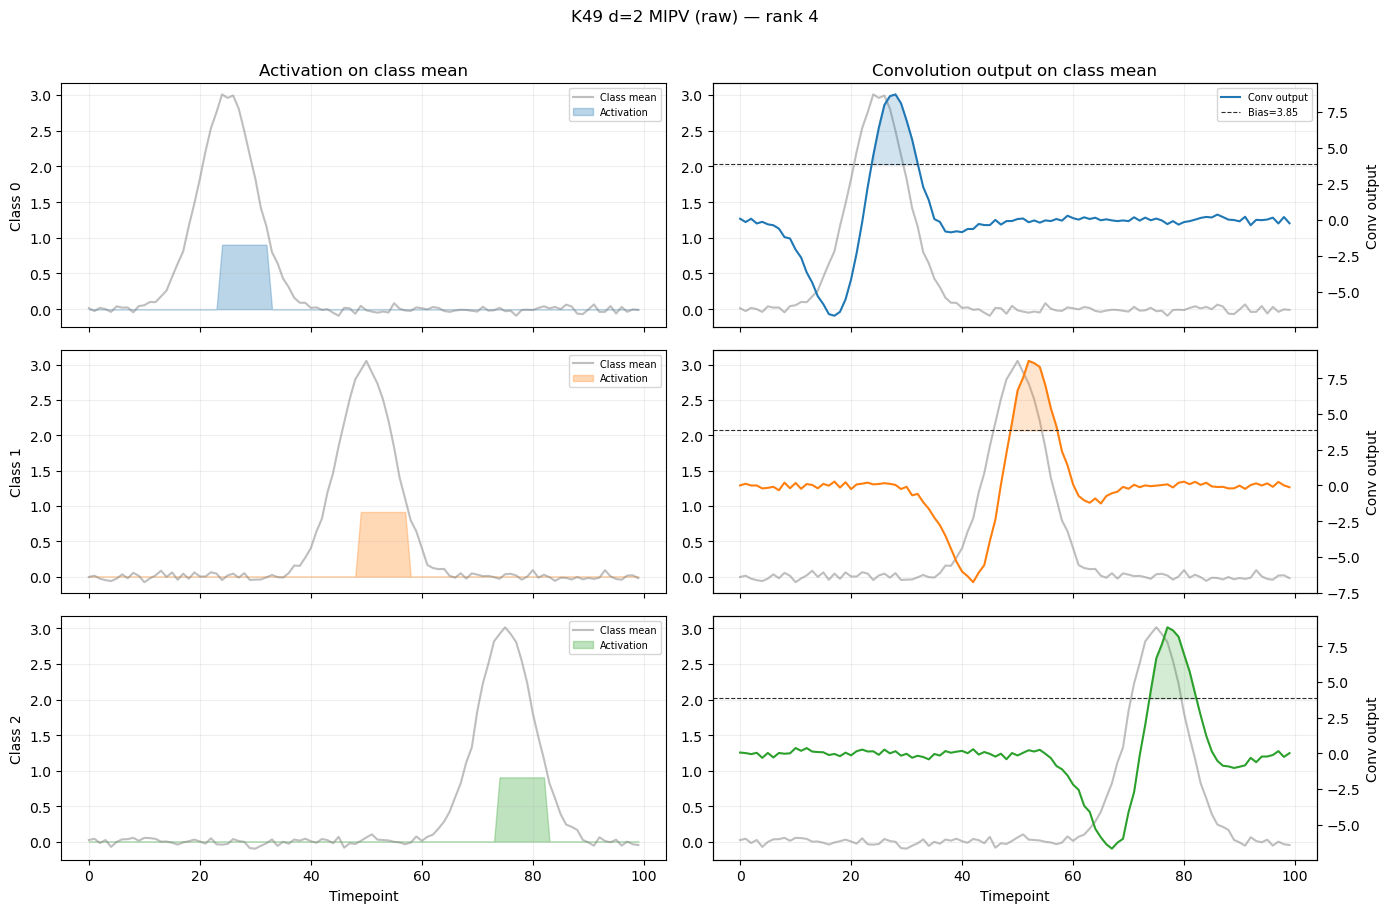

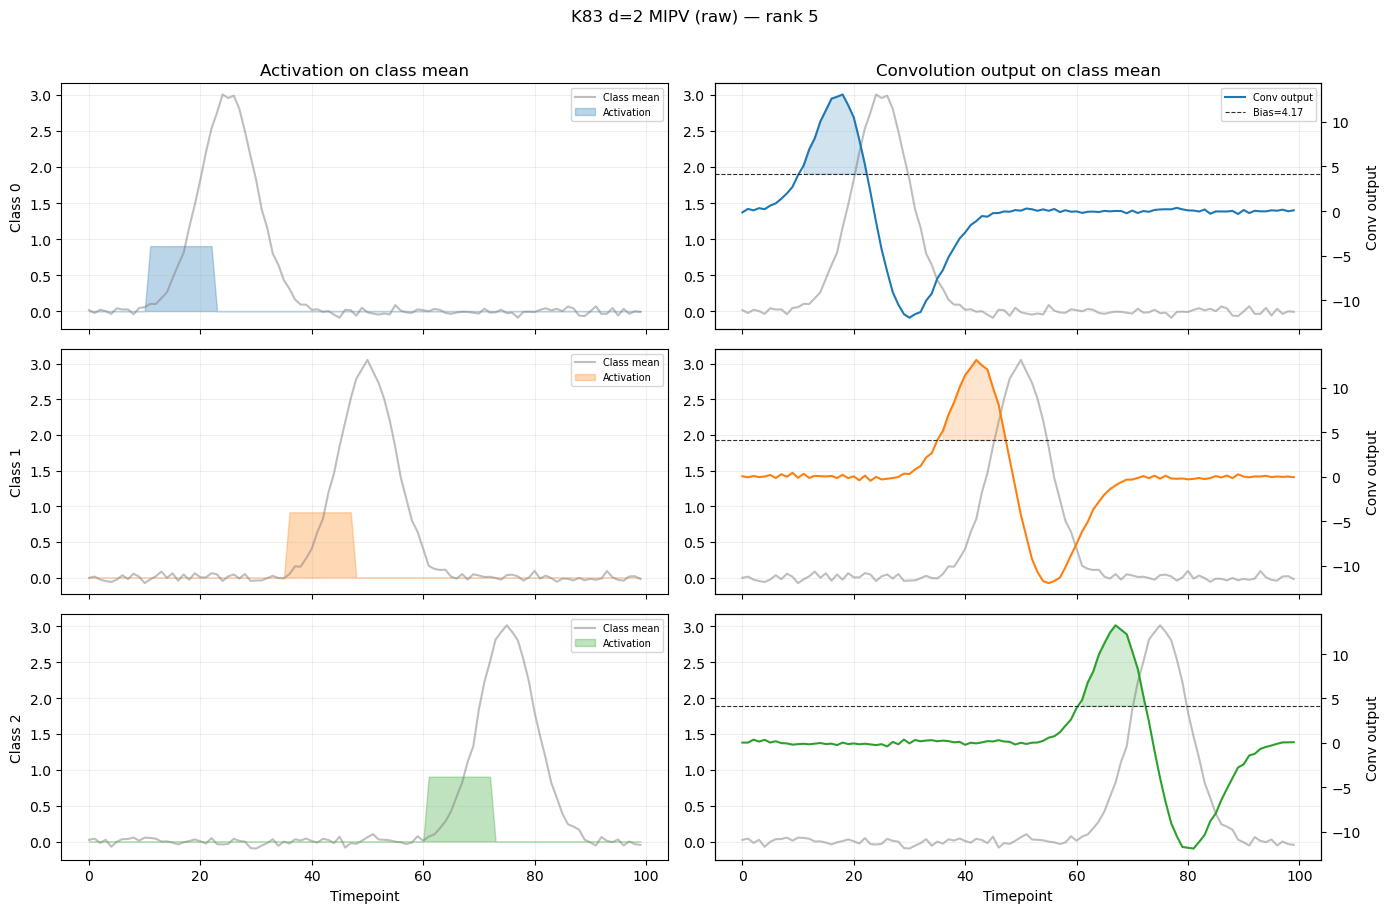

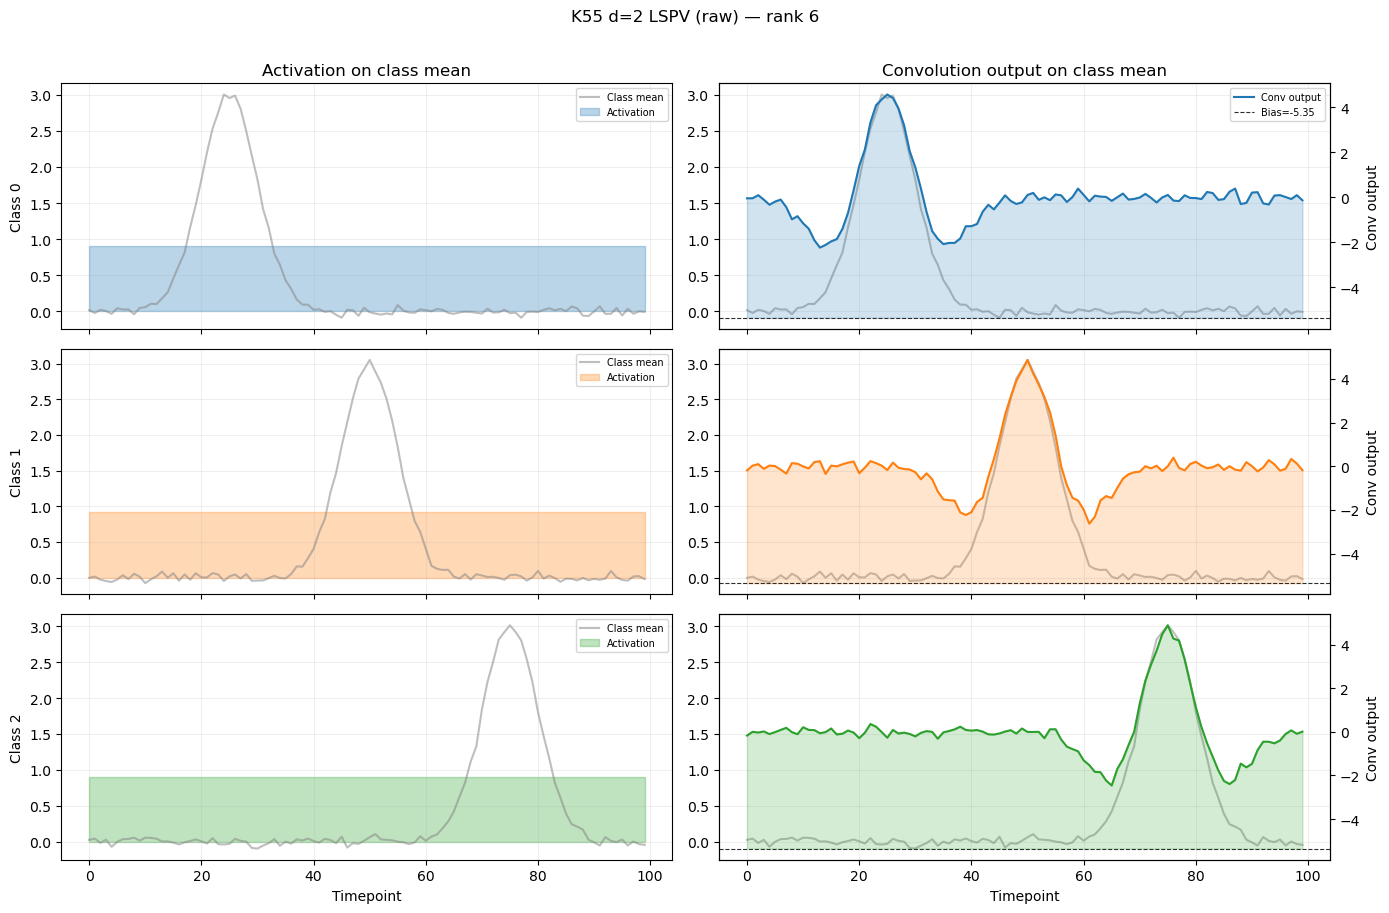

In [15]:
# Top stable features — activation and convolution on class means
top = model.get_top_features(n=6, feature_mask=stable_features)
for rank in range(len(top)):
    fig = IR.plot_class_mean_activation(
        model, X, y,
        feature_mask=stable_features,
        feature_rank=rank,
    )
    plt.show()

### Multi-kernel summary on class means

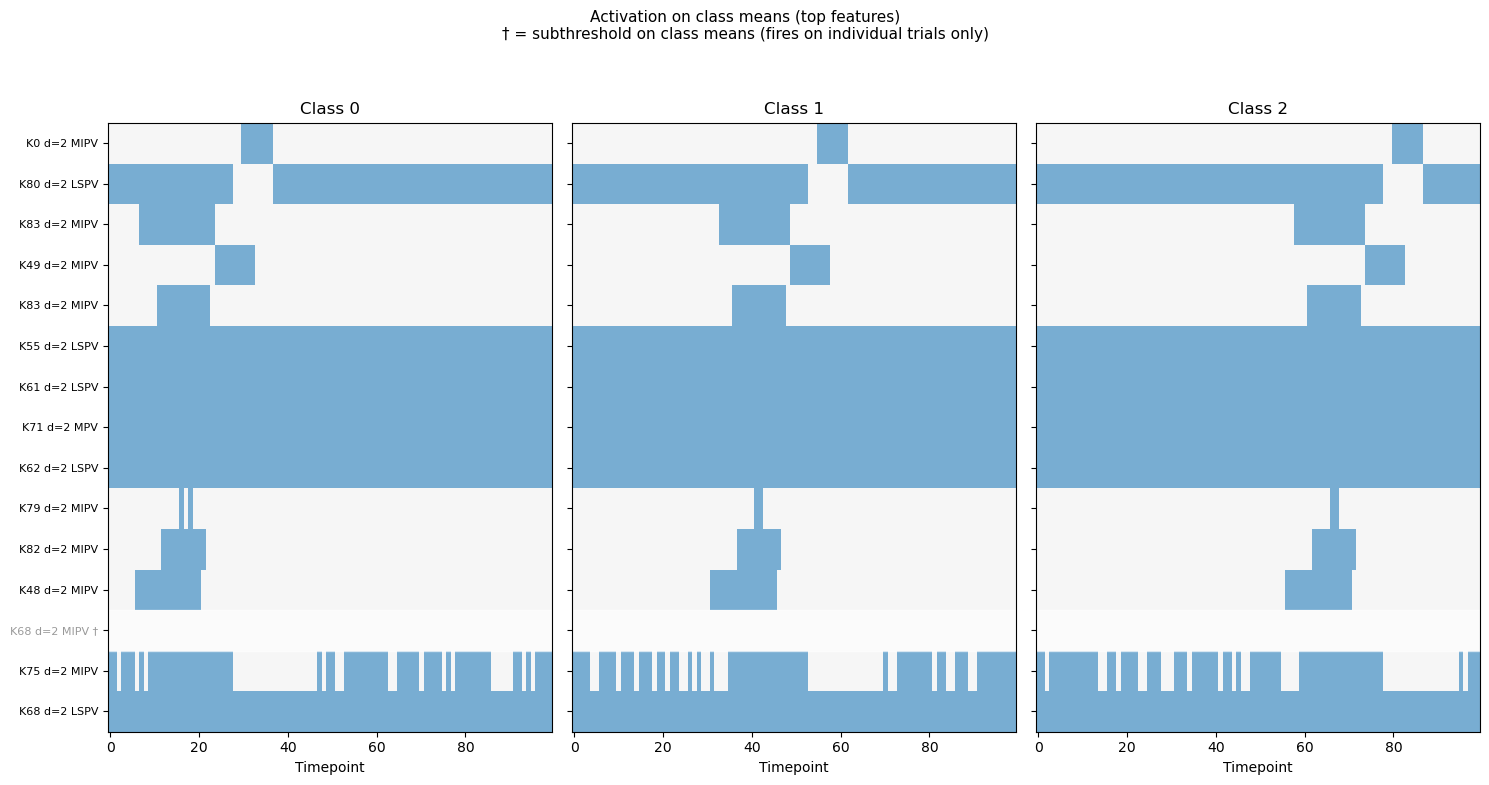

In [16]:
fig = IR.plot_multi_kernel_summary(
    model, X, y,
    feature_mask=stable_features
)

### Activations across all stable kernels for each class mean

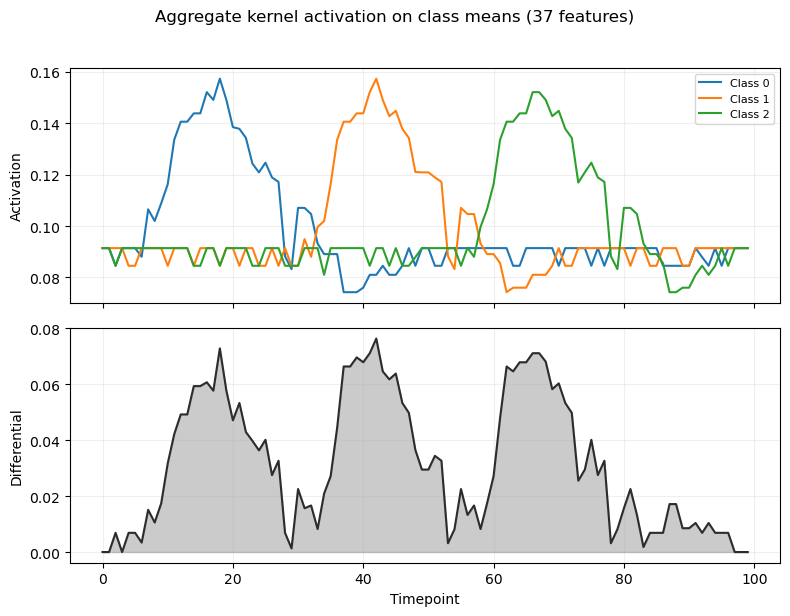

In [17]:
fig, class_act, diff = IR.plot_aggregate_activation(
    model, X, y,
    feature_mask=stable_features,
)